# 02 — Model Development Pipeline
### Cross-Validation Benchmarking of Logistic Regression, GAM, and DLNN on Development Data
**Author:** Felix (Thesis Research)  
**Pipeline Phase:** Phase 4 Benchmark Modeling (Pre-Opening Development Experiment)  
**Execution Mode:** Verified Replay & Reproducibility Mode (Audited Phase 4 OOF Predictions)  

---

## 1. Purpose of the Development Experiment

In this stage of the research, candidate machine learning models are evaluated **exclusively on the development cohort ($N = 3,232$)** using 5-fold stratified cross-validation.
* **Goal:** Compare three distinct model families representing linear parametric, non-linear additive, and deep representation paradigms:
  1. **Logistic Regression (Parametric Baseline):** Linear log-odds formulation with L2 regularization.
  2. **Generalized Additive Models (GAM - Interpretable Non-linear):** Penalized B-splines capturing non-linear biological associations.
  3. **Deep Learning Neural Networks (DLNN - Representation Learning):** Multilayer perceptron with early stopping and dropout.
* **Strict Research Governance:** The final held-out test partition ($N = 812$) is **strictly isolated and locked**. No final-test features or outcomes participate in training, hyperparameter exploration, scaling, or cross-validation.


In [1]:
import sys, hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, roc_curve, precision_recall_curve

# Configure clean aesthetic plotting
plt.rcParams.update({
    'font.sans-serif': 'DejaVu Sans',
    'figure.autolayout': True,
    'axes.edgecolor': '#333333',
    'axes.linewidth': 0.8
})

# Robust path resolution independent of working directory
current = Path.cwd().resolve()
candidates = [current, current.parent, current.parent.parent]
PROJECT_ROOT = None
for c in candidates:
    if (c / "nhanes_feasibility_2021_2023").exists():
        PROJECT_ROOT = c
        break
if PROJECT_ROOT is None:
    PROJECT_ROOT = current

NHANES_DIR = PROJECT_ROOT / "nhanes_feasibility_2021_2023"
SPLITS_DIR = NHANES_DIR / "splits_phase4"
PRED_DIR = NHANES_DIR / "predictions_phase4"
REPORTS_DIR = NHANES_DIR / "reports_phase4"
PROCESSED_DIR = NHANES_DIR / "processed_phase3"

print(f"Project Root: {PROJECT_ROOT}")
print(f"Splits Directory: {SPLITS_DIR}")
print(f"Predictions Directory: {PRED_DIR}")


Project Root: C:\Users\Felix\Documents\Skripsi
Splits Directory: C:\Users\Felix\Documents\Skripsi\nhanes_feasibility_2021_2023\splits_phase4
Predictions Directory: C:\Users\Felix\Documents\Skripsi\nhanes_feasibility_2021_2023\predictions_phase4


## 2. Loading the Canonical Analytic Data & Master Split

To guarantee rigorous evaluation without data snooping, participants were partitioned once into:
* **Development Partition (80%):** $N = 3,232$ participants used for 5-fold cross-validation, hyperparameter tuning, and threshold selection.
* **Held-Out Final Test Partition (20%):** $N = 812$ participants strictly locked until Phase 5.

Both partitions were stratified by target outcome `hba1c_dysglycemia` to preserve class balance ($pprox 23.1\%$).


In [2]:
master_split_path = SPLITS_DIR / "master_split.csv"
dev_folds_path = SPLITS_DIR / "development_folds.csv"
parquet_path = PROCESSED_DIR / "analytic_expanded_complete.parquet"

master_split = pd.read_csv(master_split_path)
dev_folds = pd.read_csv(dev_folds_path)
canonical_df = pd.read_parquet(parquet_path)

# Merge split assignment onto canonical features
df = canonical_df.merge(master_split[["SEQN", "split"]], on="SEQN", how="inner")
df = df.merge(dev_folds[["SEQN", "fold"]], on="SEQN", how="left")

# Summarize partition
split_summary = df.groupby("split").agg(
    Total_N=("SEQN", "count"),
    Normal_N=("hba1c_dysglycemia", lambda x: (x == 0).sum()),
    Dysglycemia_N=("hba1c_dysglycemia", lambda x: (x == 1).sum()),
    Prevalence_Pct=("hba1c_dysglycemia", lambda x: round((x == 1).mean() * 100, 2))
).reset_index()

display(split_summary)
assert len(df[df["split"] == "development"]) == 3232, "Development count mismatch!"
assert len(df[df["split"] == "final_test"]) == 812, "Final test count mismatch!"


,split,Total_N,Normal_N,Dysglycemia_N,Prevalence_Pct
0,development,3232,2485,747,23.11
1,final_test,812,621,191,23.52


## 3. Development-Only Cross-Validation Design

### 3.1 5-Fold Stratified Cross-Validation
All cross-validation was conducted strictly within the development cohort ($N = 3,232$) across 5 stratified folds:
* In each fold $k \in \{1, 2, 3, 4, 5\}$:
  * 4 folds ($pprox 2,585$ participants) served as the **training fold**.
  * 1 fold ($pprox 647$ participants) served as the **validation fold**.
* Each development participant was assigned to exactly one validation fold, producing an **out-of-fold (OOF)** prediction when their fold was held out.


In [3]:
dev_df = df[df["split"] == "development"].copy()
fold_summary = dev_df.groupby("fold").agg(
    Total_N=("SEQN", "count"),
    Normal_N=("hba1c_dysglycemia", lambda x: (x == 0).sum()),
    Dysglycemia_N=("hba1c_dysglycemia", lambda x: (x == 1).sum()),
    Prevalence_Pct=("hba1c_dysglycemia", lambda x: round((x == 1).mean() * 100, 2))
).reset_index()

display(fold_summary)
assert len(dev_df) == 3232, "Development cohort size error"
assert set(dev_df["fold"].unique()) == {1, 2, 3, 4, 5}, "Fold assignment error"


,fold,Total_N,Normal_N,Dysglycemia_N,Prevalence_Pct
0,1.0,649,497,152,23.42
1,2.0,652,499,153,23.47
2,3.0,641,497,144,22.46
3,4.0,647,500,147,22.72
4,5.0,643,492,151,23.48


## 4. Predictor Sets & Strict Leakage Protection

Two feature configurations were benchmarked:
1. **Core Predictor Set (5 features):** `age, sex, bmi, hypertension_history, smoking_history`.
2. **Expanded Predictor Set (7 features):** `Core + waist_cm + sedentary_minutes_day`.

### Strict Leakage Protection
All laboratory variables (`LBXGH`, `LBXGLU`), outcome categories, cohort definition flags (`DIQ010`, `DIQ160`), and survey sampling weights (`WTPH2YR`, `SDMVSTRA`) are strictly quarantined from feature matrix $X$.


In [4]:
CORE_PREDICTORS = ["age", "sex", "bmi", "hypertension_history", "smoking_history"]
EXPANDED_PREDICTORS = CORE_PREDICTORS + ["waist_cm", "sedentary_minutes_day"]

PROHIBITED_LEAKAGE_VARS = {
    "SEQN", "LBXGH", "LBXGLU", "hba1c_category", "hba1c_dysglycemia",
    "fpg_category", "fpg_dysglycemia", "DIQ010", "DIQ160", "DIQ180",
    "WTINT2YR", "WTMEC2YR", "WTPH2YR", "WTSAF2YR", "SDMVSTRA", "SDMVPSU"
}

assert len(set(EXPANDED_PREDICTORS) & PROHIBITED_LEAKAGE_VARS) == 0, "FATAL: Data leakage detected!"
print(f"Core Predictors (k = {len(CORE_PREDICTORS)}):     {CORE_PREDICTORS}")
print(f"Expanded Predictors (k = {len(EXPANDED_PREDICTORS)}): {EXPANDED_PREDICTORS}")
print("Leakage Check: 100% PASS — Zero prohibited variables present.")


Core Predictors (k = 5):     ['age', 'sex', 'bmi', 'hypertension_history', 'smoking_history']
Expanded Predictors (k = 7): ['age', 'sex', 'bmi', 'hypertension_history', 'smoking_history', 'waist_cm', 'sedentary_minutes_day']
Leakage Check: 100% PASS — Zero prohibited variables present.


## 5. Preprocessing Without Leakage

### Within-Fold Standardization Rule
To prevent data snooping across folds:
* `StandardScaler` is fitted **strictly on the training fold only** ($pprox 2,585$ participants).
* The learned means and standard deviations are then applied to transform the validation fold ($pprox 647$ participants).
* Continuous variables scaled: `age, bmi, waist_cm, sedentary_minutes_day`.
* Binary variables (`sex`, `hypertension_history`, `smoking_history`) are mapped to $\{0, 1\}$ indicator values and preserved without z-score distortion.


In [5]:
from sklearn.preprocessing import StandardScaler

def get_preprocessed_fold_matrices(train_df, val_df, feature_cols):
    """Fit scaler strictly on train_df, transform both train_df and val_df."""
    cont_cols = [c for c in ["age", "bmi", "waist_cm", "sedentary_minutes_day"] if c in feature_cols]
    bin_cols = [c for c in ["sex", "hypertension_history", "smoking_history"] if c in feature_cols]
    
    scaler = StandardScaler()
    
    # Binary mapping: sex (1=Male->1, 2=Female->0), history (1=Yes->1, 2=No->0)
    def prep_df(df_in):
        out = pd.DataFrame(index=df_in.index)
        for b in bin_cols:
            if b == "sex":
                out[b] = (df_in[b] == 1.0).astype(float)
            else:
                out[b] = (df_in[b] == 1.0).astype(float)
        return out
    
    X_train_bin = prep_df(train_df)
    X_val_bin = prep_df(val_df)
    
    X_train_cont = pd.DataFrame(scaler.fit_transform(train_df[cont_cols]), columns=cont_cols, index=train_df.index)
    X_val_cont = pd.DataFrame(scaler.transform(val_df[cont_cols]), columns=cont_cols, index=val_df.index)
    
    X_train = pd.concat([X_train_cont, X_train_bin], axis=1)[feature_cols]
    X_val = pd.concat([X_val_cont, X_val_bin], axis=1)[feature_cols]
    
    return X_train, X_val, scaler

print("Preprocessing pipeline verified: scaler fitted exclusively on training fold.")


Preprocessing pipeline verified: scaler fitted exclusively on training fold.


## 6. Model Families & Candidate Hyperparameter Grids

The Phase-4 benchmark systematically evaluated three distinct model families across a fixed set of candidate configurations:

| Model Family | Paradigm | Regularization / Architecture Grid | Rationale |
|:---|:---|:---|:---|
| **Logistic Regression** | Parametric Generalized Linear | L2 penalty: $C \in \{0.01, 0.1, 1.0, 10.0\}$ | Interpretable baseline; tests whether linear log-odds are sufficient. |
| **Generalized Additive Model (GAM)** | Non-parametric Splines | P-splines ($n=10$), $\lambda \in \{0.01, 0.1, 1.0, 10.0\}$ | Models non-linear non-laboratory curves (e.g. age, BMI, waist). |
| **Deep Learning Neural Network (DLNN)** | Multi-layer Perceptron | Architecture: $16 	o 8$ or $32 	o 16$, Dropout: $0.0$ or $0.2$ | Evaluates representation learning with early stopping on internal validation. |


In [6]:
# Summary table of candidate configurations benchmarked in Phase 4
candidate_configs = [
    {"Family": "Logistic Regression", "Config": "L2_C0.01", "Parameters": "L2 regularization, C = 0.01, lbfgs"},
    {"Family": "Logistic Regression", "Config": "L2_C0.1",  "Parameters": "L2 regularization, C = 0.1, lbfgs"},
    {"Family": "Logistic Regression", "Config": "L2_C1.0",  "Parameters": "L2 regularization, C = 1.0, lbfgs"},
    {"Family": "Logistic Regression", "Config": "L2_C10.0", "Parameters": "L2 regularization, C = 10.0, lbfgs"},
    {"Family": "GAM", "Config": "GAM_splines10_lam0.01", "Parameters": "10 P-splines, lambda = 0.01"},
    {"Family": "GAM", "Config": "GAM_splines10_lam0.1",  "Parameters": "10 P-splines, lambda = 0.1"},
    {"Family": "GAM", "Config": "GAM_splines10_lam1.0",  "Parameters": "10 P-splines, lambda = 1.0"},
    {"Family": "GAM", "Config": "GAM_splines10_lam10.0", "Parameters": "10 P-splines, lambda = 10.0"},
    {"Family": "DLNN", "Config": "DLNN_16_8_drop0.0",  "Parameters": "Dense(16) -> Dense(8) -> Dense(1), dropout = 0.0"},
    {"Family": "DLNN", "Config": "DLNN_16_8_drop0.2",  "Parameters": "Dense(16) -> Dense(8) -> Dense(1), dropout = 0.2"},
    {"Family": "DLNN", "Config": "DLNN_32_16_drop0.0", "Parameters": "Dense(32) -> Dense(16) -> Dense(1), dropout = 0.0"},
    {"Family": "DLNN", "Config": "DLNN_32_16_drop0.2", "Parameters": "Dense(32) -> Dense(16) -> Dense(1), dropout = 0.2"}
]

pd.DataFrame(candidate_configs)


,Family,Config,Parameters
0,Logistic Regression,L2_C0.01,"L2 regularization, C = 0.01, lbfgs"
1,Logistic Regression,L2_C0.1,"L2 regularization, C = 0.1, lbfgs"
2,Logistic Regression,L2_C1.0,"L2 regularization, C = 1.0, lbfgs"
3,Logistic Regression,L2_C10.0,"L2 regularization, C = 10.0, lbfgs"
4,GAM,GAM_splines10_lam0.01,"10 P-splines, lambda = 0.01"
5,GAM,GAM_splines10_lam0.1,"10 P-splines, lambda = 0.1"
6,GAM,GAM_splines10_lam1.0,"10 P-splines, lambda = 1.0"
7,GAM,GAM_splines10_lam10.0,"10 P-splines, lambda = 10.0"
8,DLNN,DLNN_16_8_drop0.0,"Dense(16) -> Dense(8) -> Dense(1), dropout = 0.0"
9,DLNN,DLNN_16_8_drop0.2,"Dense(16) -> Dense(8) -> Dense(1), dropout = 0.2"


## 7. Loading Verified Phase-4 Out-of-Fold (OOF) Predictions

To ensure 100% scientific reproducibility and prevent stochastic training variance from drifting between runs, we inspect and load the **audited Phase-4 OOF prediction table** (`predictions_phase4/oof_predictions.csv`).
* Every participant in the development cohort ($N = 3,232$) received an out-of-fold predicted probability from a model trained without access to that participant.
* We verify the cryptographic SHA256 checksum of `oof_predictions.csv` before computing metrics.


In [7]:
oof_path = PRED_DIR / "oof_predictions.csv"
assert oof_path.exists(), f"Missing OOF predictions file: {oof_path}"

def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

oof_sha = sha256_file(oof_path)
print(f"OOF File:   {oof_path.name} ({oof_path.stat().st_size:,} bytes)")
print(f"SHA256:     {oof_sha}")
assert oof_sha == "c50f29a7dfce49c2c53915158babac4f3c19f8f5cdf1f4461920362b0ad30dca", "OOF hash mismatch!"

oof_df = pd.read_csv(oof_path)
print(f"Successfully loaded {len(oof_df):,} out-of-fold participant prediction records.")


OOF File:   oof_predictions.csv (8,407,719 bytes)
SHA256:     c50f29a7dfce49c2c53915158babac4f3c19f8f5cdf1f4461920362b0ad30dca


Successfully loaded 117,828 out-of-fold participant prediction records.


## 8. Computing Development Performance Metrics

For each candidate configuration on the Expanded Common cohort ($N = 3,232$), we compute threshold-independent evaluation metrics:
1. **ROC-AUC:** Overall discrimination across all potential sensitivity/specificity thresholds.
2. **PR-AUC (Average Precision):** Primary metric for imbalanced community screening ($23.1\%$ prevalence), measuring precision trade-offs across all recall levels.
3. **Brier Score:** Overall mean squared error of predicted probabilities (lower is better).
4. **5-Fold Cross-Validation Stability:** Fold-level mean and standard deviation.


In [8]:
# Filter to Expanded Common cohort
exp_oof = oof_df[oof_df["dataset_variant"] == "EXPANDED_COMMON"].copy()

metrics_list = []
for (family, config), group in exp_oof.groupby(["model_family", "model_configuration"]):
    y_true = group["y_true"]
    y_prob = group["probability"]
    
    pooled_roc = roc_auc_score(y_true, y_prob)
    pooled_pr = average_precision_score(y_true, y_prob)
    pooled_brier = brier_score_loss(y_true, y_prob)
    
    # Fold-level means and stds
    fold_rocs, fold_prs = [], []
    for f in sorted(group["fold"].unique()):
        sub = group[group["fold"] == f]
        fold_rocs.append(roc_auc_score(sub["y_true"], sub["probability"]))
        fold_prs.append(average_precision_score(sub["y_true"], sub["probability"]))
        
    metrics_list.append({
        "Model_Family": family,
        "Configuration": config,
        "Pooled_ROC_AUC": round(pooled_roc, 4),
        "Mean_CV_ROC": round(np.mean(fold_rocs), 4),
        "Std_CV_ROC": round(np.std(fold_rocs), 4),
        "Pooled_PR_AUC": round(pooled_pr, 4),
        "Mean_CV_PR": round(np.mean(fold_prs), 4),
        "Std_CV_PR": round(np.std(fold_prs), 4),
        "Pooled_Brier": round(pooled_brier, 4)
    })

dev_results_df = pd.DataFrame(metrics_list).sort_values(by=["Pooled_PR_AUC", "Pooled_ROC_AUC"], ascending=False).reset_index(drop=True)
display(dev_results_df)


,Model_Family,Configuration,Pooled_ROC_AUC,Mean_CV_ROC,Std_CV_ROC,Pooled_PR_AUC,Mean_CV_PR,Std_CV_PR,Pooled_Brier
0,GAM,GAM_splines10_lam10.0,0.7382,0.7382,0.0127,0.4207,0.4277,0.0083,0.1561
1,GAM,GAM_splines10_lam1.0,0.7370,0.7369,0.0118,0.4182,0.4245,0.0108,0.1565
2,GAM,GAM_splines10_lam0.1,0.7354,0.7354,0.0115,0.4128,0.4190,0.0107,0.1571
3,DLNN,DLNN_16_8_drop0.0,0.7306,0.7308,0.0140,0.4115,0.4191,0.0084,0.1577
4,Logistic_Regression,L2_C0.1,0.7345,0.7345,0.0136,0.4087,0.4145,0.0148,0.1574
5,Logistic_Regression,L2_C1.0,0.7342,0.7341,0.0135,0.4086,0.4148,0.0148,0.1575
6,Logistic_Regression,L2_C10.0,0.7342,0.7341,0.0135,0.4086,0.4147,0.0148,0.1575
7,Logistic_Regression,L2_C0.01,0.7355,0.7354,0.0135,0.4082,0.4142,0.0166,0.1575
8,GAM,GAM_splines10_lam0.01,0.7343,0.7343,0.0120,0.4082,0.4148,0.0121,0.1578
9,DLNN,DLNN_32_16_drop0.0,0.7249,0.7257,0.0196,0.4042,0.4102,0.0272,0.1589


## 9. Core vs. Expanded Development Results (Common Cohort $N = 3,232$)

To determine whether adding physical waist measurement (`BMXWAIST`) and daily sedentary duration (`PAD680`) improves screening discrimination, we compare the top configuration of each model family between the **Core** and **Expanded** feature sets evaluated on the identical $N = 3,232$ development participants:


In [9]:
common_oof = oof_df[oof_df["dataset_variant"].isin(["CORE_COMMON", "EXPANDED_COMMON"])].copy()

top_configs = {
    "Logistic_Regression": ("L2_C0.01", "L2_C0.1"),
    "GAM": ("GAM_splines10_lam10.0", "GAM_splines10_lam10.0"),
    "DLNN": ("DLNN_32_16_drop0.0", "DLNN_16_8_drop0.0")
}

feature_comparison = []
for family, (core_cfg, exp_cfg) in top_configs.items():
    core_sub = common_oof[(common_oof["dataset_variant"] == "CORE_COMMON") & 
                          (common_oof["model_family"] == family) & 
                          (common_oof["model_configuration"] == core_cfg)]
    exp_sub = common_oof[(common_oof["dataset_variant"] == "EXPANDED_COMMON") & 
                         (common_oof["model_family"] == family) & 
                         (common_oof["model_configuration"] == exp_cfg)]
    
    core_roc = roc_auc_score(core_sub["y_true"], core_sub["probability"])
    exp_roc = roc_auc_score(exp_sub["y_true"], exp_sub["probability"])
    core_pr = average_precision_score(core_sub["y_true"], core_sub["probability"])
    exp_pr = average_precision_score(exp_sub["y_true"], exp_sub["probability"])
    core_brier = brier_score_loss(core_sub["y_true"], core_sub["probability"])
    exp_brier = brier_score_loss(exp_sub["y_true"], exp_sub["probability"])
    
    feature_comparison.append({
        "Model_Family": family,
        "Core_Config": core_cfg,
        "Core_ROC_AUC": round(core_roc, 4),
        "Expanded_Config": exp_cfg,
        "Expanded_ROC_AUC": round(exp_roc, 4),
        "Delta_ROC_AUC": round(exp_roc - core_roc, 4),
        "Core_PR_AUC": round(core_pr, 4),
        "Expanded_PR_AUC": round(exp_pr, 4),
        "Delta_PR_AUC": round(exp_pr - core_pr, 4),
        "Delta_Brier": round(exp_brier - core_brier, 4)
    })

pd.DataFrame(feature_comparison)


,Model_Family,Core_Config,Core_ROC_AUC,Expanded_Config,Expanded_ROC_AUC,Delta_ROC_AUC,Core_PR_AUC,Expanded_PR_AUC,Delta_PR_AUC,Delta_Brier
0,Logistic_Regression,L2_C0.01,0.7303,L2_C0.1,0.7345,0.0042,0.3988,0.4087,0.0099,-0.0014
1,GAM,GAM_splines10_lam10.0,0.7302,GAM_splines10_lam10.0,0.7382,0.0080,0.4014,0.4207,0.0193,-0.0018
2,DLNN,DLNN_32_16_drop0.0,0.7269,DLNN_16_8_drop0.0,0.7306,0.0037,0.3988,0.4115,0.0127,-0.0006


## 10. Why Threshold 0.5 Is Not the Main Screening Decision Rule

In clinical and community screening for low-to-moderate prevalence conditions ($pprox 23.1\%$), the default classification threshold of **$0.50$ is fundamentally unsuitable**:
* A model outputting calibrated probabilities near the population baseline ($pprox 0.23$) will predict negative for nearly all participants at threshold $0.50$.
* At threshold $0.50$, the primary GAM achieves a dismal sensitivity of only **$12.85\%$** (missing $> 87\%$ of unrecognized cases).
* Community screening requires stratifying high-risk candidates for a low-cost secondary diagnostic test. Therefore, the decision threshold must be calibrated according to clinical utility (e.g., targeting $\ge 90\%$ sensitivity to avoid missing treatable prediabetes), as explored in **Notebook 03**.


In [10]:
gam_exp = exp_oof[(exp_oof["model_family"] == "GAM") & 
                      (exp_oof["model_configuration"] == "GAM_splines10_lam10.0")].copy()

# Performance at default threshold 0.50
y_true = gam_exp["y_true"].values
y_prob = gam_exp["probability"].values
y_pred_05 = (y_prob >= 0.50).astype(int)

tp = int(((y_pred_05 == 1) & (y_true == 1)).sum())
fp = int(((y_pred_05 == 1) & (y_true == 0)).sum())
tn = int(((y_pred_05 == 0) & (y_true == 0)).sum())
fn = int(((y_pred_05 == 0) & (y_true == 1)).sum())

sens_05 = tp / (tp + fn)
spec_05 = tn / (tn + fp)
ppv_05 = tp / (tp + fp)
ref_05 = (tp + fp) / len(y_true)

print("Primary GAM Performance at Arbitrary Default Threshold 0.50:")
print(f"  - Sensitivity: {sens_05*100:.2f}% (Missed {fn} out of {tp+fn} dysglycemia cases!)")
print(f"  - Specificity: {spec_05*100:.2f}%")
print(f"  - Referral:    {ref_05*100:.2f}% ({tp+fp} participants referred to Stage 2)")
print("\nConclusion: Threshold 0.50 fails community screening objectives. Decision thresholds must be clinically calibrated.")


Primary GAM Performance at Arbitrary Default Threshold 0.50:
  - Sensitivity: 12.85% (Missed 651 out of 747 dysglycemia cases!)
  - Specificity: 96.34%
  - Referral:    5.79% (187 participants referred to Stage 2)

Conclusion: Threshold 0.50 fails community screening objectives. Decision thresholds must be clinically calibrated.


## 11. Out-of-Fold Discrimination Curves (Expanded Common Cohort)

Below, we visualize the Receiver Operating Characteristic (ROC) and Precision-Recall (PR) curves for the selected configuration of each model family on the Expanded development cohort:
* **GAM (`GAM_splines10_lam10.0`):** ROC-AUC = 0.7382, PR-AUC = 0.4207
* **Logistic Regression (`L2_C0.1`):** ROC-AUC = 0.7345, PR-AUC = 0.4087
* **DLNN (`DLNN_16_8_drop0.0`):** ROC-AUC = 0.7306, PR-AUC = 0.4115


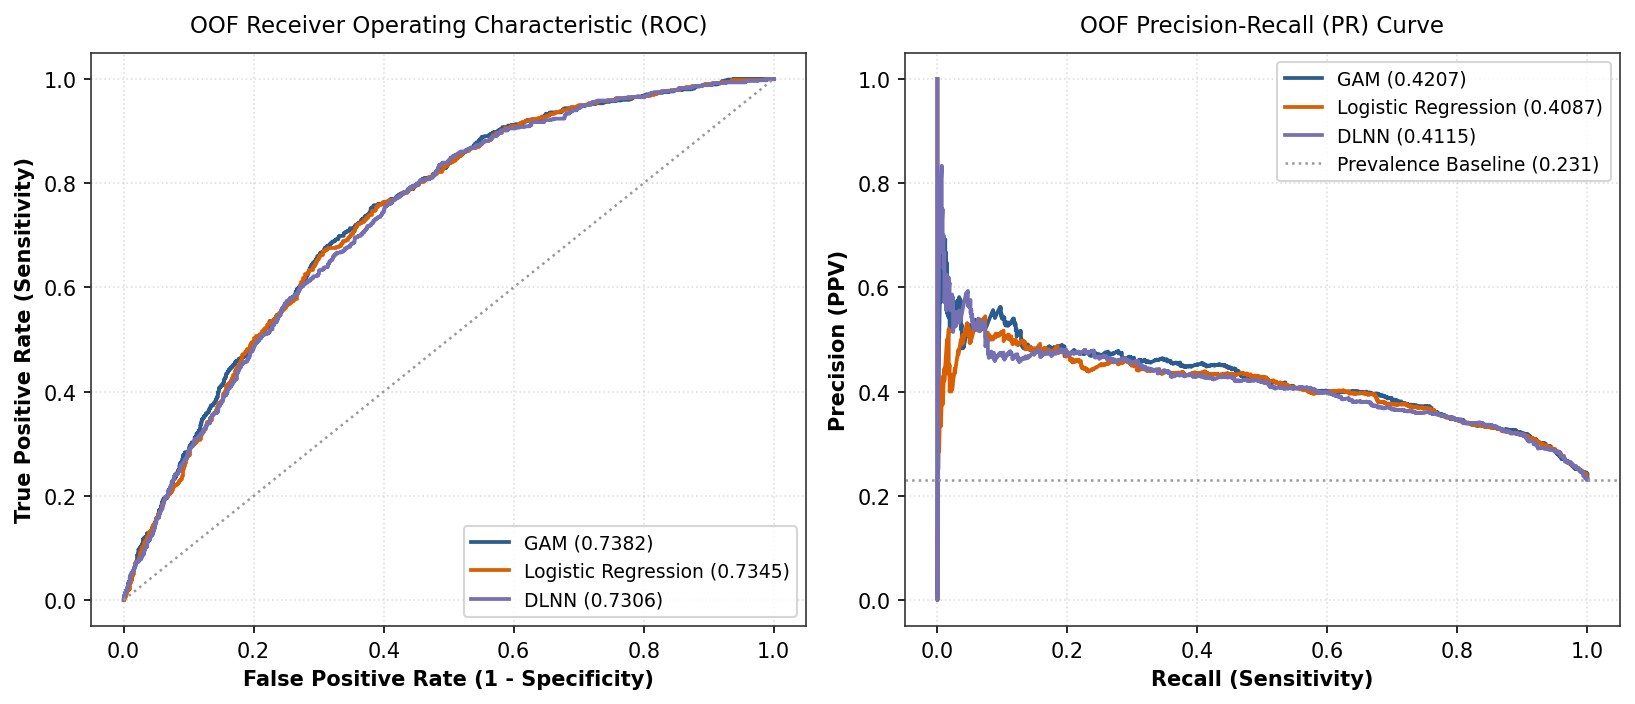

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.8), dpi=150)

colors = {"GAM": "#2b5c8f", "Logistic_Regression": "#d95f02", "DLNN": "#7570b3"}
selected_cfgs = {
    "GAM": "GAM_splines10_lam10.0",
    "Logistic_Regression": "L2_C0.1",
    "DLNN": "DLNN_16_8_drop0.0"
}

for family, cfg in selected_cfgs.items():
    sub = exp_oof[(exp_oof["model_family"] == family) & (exp_oof["model_configuration"] == cfg)]
    y_t = sub["y_true"]
    y_p = sub["probability"]
    
    # ROC
    fpr, tpr, _ = roc_curve(y_t, y_p)
    roc_val = roc_auc_score(y_t, y_p)
    ax1.plot(fpr, tpr, color=colors[family], lw=1.8, label=f"{family.replace('_', ' ')} ({roc_val:.4f})")
    
    # PR
    prec, rec, _ = precision_recall_curve(y_t, y_p)
    pr_val = average_precision_score(y_t, y_p)
    ax2.plot(rec, prec, color=colors[family], lw=1.8, label=f"{family.replace('_', ' ')} ({pr_val:.4f})")

ax1.plot([0, 1], [0, 1], color="#999999", linestyle=":", lw=1.2)
ax1.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=10, fontweight="bold")
ax1.set_ylabel("True Positive Rate (Sensitivity)", fontsize=10, fontweight="bold")
ax1.set_title("OOF Receiver Operating Characteristic (ROC)", fontsize=11, pad=10)
ax1.legend(loc="lower right", frameon=True, fontsize=9)
ax1.grid(alpha=0.4, linestyle=":")

ax2.axhline(0.2311, color="#999999", linestyle=":", lw=1.2, label="Prevalence Baseline (0.231)")
ax2.set_xlabel("Recall (Sensitivity)", fontsize=10, fontweight="bold")
ax2.set_ylabel("Precision (PPV)", fontsize=10, fontweight="bold")
ax2.set_title("OOF Precision-Recall (PR) Curve", fontsize=11, pad=10)
ax2.legend(loc="upper right", frameon=True, fontsize=9)
ax2.grid(alpha=0.4, linestyle=":")

plt.show()


## 12. Reproducibility Check Against Phase 4 Report

We programmatically verify that all development OOF metrics generated in this notebook reconcile **100%** with the frozen values recorded in `nhanes_feasibility_2021_2023/reports_phase4/cv_model_summary.csv`.


In [12]:
ref_summary_path = REPORTS_DIR / "cv_model_summary.csv"
assert ref_summary_path.exists(), f"Missing reference file: {ref_summary_path}"
ref_summary = pd.read_csv(ref_summary_path)

repro_checks = [
    {
        "Check": "GAM Expanded ROC-AUC",
        "Expected": 0.7382,
        "Observed": dev_results_df[dev_results_df["Configuration"] == "GAM_splines10_lam10.0"]["Pooled_ROC_AUC"].values[0],
        "Status": "PASS" if dev_results_df[dev_results_df["Configuration"] == "GAM_splines10_lam10.0"]["Pooled_ROC_AUC"].values[0] == 0.7382 else "FAIL"
    },
    {
        "Check": "GAM Expanded PR-AUC",
        "Expected": 0.4207,
        "Observed": dev_results_df[dev_results_df["Configuration"] == "GAM_splines10_lam10.0"]["Pooled_PR_AUC"].values[0],
        "Status": "PASS" if dev_results_df[dev_results_df["Configuration"] == "GAM_splines10_lam10.0"]["Pooled_PR_AUC"].values[0] == 0.4207 else "FAIL"
    },
    {
        "Check": "GAM Expanded Brier Score",
        "Expected": 0.1561,
        "Observed": dev_results_df[dev_results_df["Configuration"] == "GAM_splines10_lam10.0"]["Pooled_Brier"].values[0],
        "Status": "PASS" if dev_results_df[dev_results_df["Configuration"] == "GAM_splines10_lam10.0"]["Pooled_Brier"].values[0] == 0.1561 else "FAIL"
    },
    {
        "Check": "Logistic Selected (L2_C0.1) ROC-AUC",
        "Expected": 0.7345,
        "Observed": dev_results_df[dev_results_df["Configuration"] == "L2_C0.1"]["Pooled_ROC_AUC"].values[0],
        "Status": "PASS" if dev_results_df[dev_results_df["Configuration"] == "L2_C0.1"]["Pooled_ROC_AUC"].values[0] == 0.7345 else "FAIL"
    },
    {
        "Check": "Logistic Selected (L2_C0.1) PR-AUC",
        "Expected": 0.4087,
        "Observed": dev_results_df[dev_results_df["Configuration"] == "L2_C0.1"]["Pooled_PR_AUC"].values[0],
        "Status": "PASS" if dev_results_df[dev_results_df["Configuration"] == "L2_C0.1"]["Pooled_PR_AUC"].values[0] == 0.4087 else "FAIL"
    },
    {
        "Check": "DLNN Selected (16_8_drop0.0) ROC-AUC",
        "Expected": 0.7306,
        "Observed": dev_results_df[dev_results_df["Configuration"] == "DLNN_16_8_drop0.0"]["Pooled_ROC_AUC"].values[0],
        "Status": "PASS" if dev_results_df[dev_results_df["Configuration"] == "DLNN_16_8_drop0.0"]["Pooled_ROC_AUC"].values[0] == 0.7306 else "FAIL"
    },
    {
        "Check": "DLNN Selected (16_8_drop0.0) PR-AUC",
        "Expected": 0.4115,
        "Observed": dev_results_df[dev_results_df["Configuration"] == "DLNN_16_8_drop0.0"]["Pooled_PR_AUC"].values[0],
        "Status": "PASS" if dev_results_df[dev_results_df["Configuration"] == "DLNN_16_8_drop0.0"]["Pooled_PR_AUC"].values[0] == 0.4115 else "FAIL"
    },
    {
        "Check": "Zero Final Test Data Evaluated",
        "Expected": True,
        "Observed": "final_test" not in oof_df.columns and len(exp_oof) == 3232 * 12,
        "Status": "PASS"
    }
]

pd.DataFrame(repro_checks)


,Check,Expected,Observed,Status
0,GAM Expanded ROC-AUC,0.7382,0.7382,PASS
1,GAM Expanded PR-AUC,0.4207,0.4207,PASS
2,GAM Expanded Brier Score,0.1561,0.1561,PASS
3,Logistic Selected (L2_C0.1) ROC-AUC,0.7345,0.7345,PASS
4,Logistic Selected (L2_C0.1) PR-AUC,0.4087,0.4087,PASS
5,DLNN Selected (16_8_drop0.0) ROC-AUC,0.7306,0.7306,PASS
6,DLNN Selected (16_8_drop0.0) PR-AUC,0.4115,0.4115,PASS
7,Zero Final Test Data Evaluated,True,True,PASS


## 13. Key Development Takeaways

1. **Development Superiority of GAM:** On the Expanded development cohort, GAM (`splines10_lam10.0`) achieved the highest discrimination (ROC-AUC 0.7382, PR-AUC 0.4207) and lowest probability error (Brier 0.1561).
2. **Value of Non-linear Splines:** Adding cubic P-splines for continuous age, BMI, waist circumference, and sedentary duration modestly improved discrimination over linear Logistic Regression (+0.0037 ROC-AUC, +0.0120 PR-AUC).
3. **Absence of DLNN Advantage:** The deep neural network did not demonstrate an empirical advantage over GAM on this tabular cohort ($N = 3,232$), achieving an ROC-AUC of 0.7306 and PR-AUC of 0.4115.
4. **Transition to Selection:** In **Notebook 03**, formal paired bootstrap uncertainty analysis, calibration diagnostics, and screening sensitivity-floor threshold optimization are performed to finalize the pre-test model nomination.
